### Graph

In [1]:
from database.DBConnector import t_get_unprocessed_chunks_input, t_get_chunks_input
from graph.graph_config import create_app
from graph.states_setup import save_output_as_json
from tqdm import tqdm

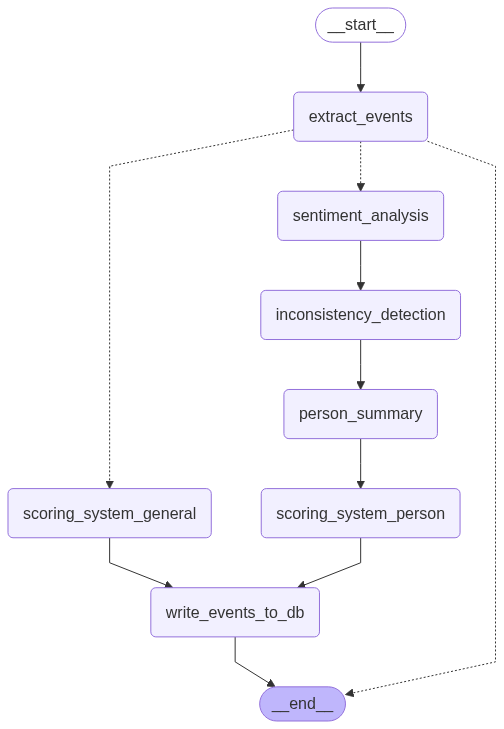

In [2]:
app = create_app()
app

In [3]:
extracted_df = t_get_chunks_input(is_processed=1)
extracted_df

,chunk_id,content,topic,topic_id,article_date,origin_article_id
0,145,A new blueprint from the Biden administration ...,Green energy,1,2021-09-08,45
1,146,What's in the Democrats' $3.5 trillion spendin...,Green energy,1,2021-09-08,45
2,147,"As the climate crisis escalates, the world is ...",Green energy,1,2021-08-31,46
3,148,".Operating a plane or a large ship, for instan...",Green energy,1,2021-08-31,46
4,149,". Methane, a powerful greenhouse gas and the m...",Green energy,1,2021-08-31,46
5,150,.” Jackson is also the CEO and founder of Prot...,Green energy,1,2021-08-31,46
6,151,Scientists say this invisible gas could seal o...,Green energy,1,2021-08-31,46
7,152,ESG investing — funds that are conscious of co...,Green energy,1,2021-08-16,47
8,153,. Apple’s manufacturing contributed more than ...,Green energy,1,2021-08-16,47
9,154,.“Trying to find the perfect company is imposs...,Green energy,1,2021-08-16,47


In [4]:
# extracted_df = t_get_unprocessed_chunks_input()
# extracted_df

66,68 - bad json?
67,69,70,71 - missing person id
not working retries in event_classifier?

209 - usual

In [5]:
elem = extracted_df.iloc[0].to_dict()
elem

{'chunk_id': 145,
 'content': "A new blueprint from the Biden administration shows how solar energy could play a massive role in transitioning the United States’ power sector to clean energy, and achieve the President’s ambitious goals to decarbonize the US economy.The Solar Futures Study from the Department of Energy, released Wednesday, shows that by 2035, solar energy has the potential to power 40% of the nation’s electricity and employ as many as 1.5 million people — without raising electricity costs for consumers.Though the report shows reaching 40% solar is possible, that goal is contingent on Congress passing legislation that incentivizes renewable energy as well as the widespread adoption of solar power. Congressional Democrats are currently negotiating a $3.5 trillion spending bill that includes tax credits for wind and solar power, but it faces a tough fight this fall.“The study illuminates the fact that solar, our cheapest and fastest-growing source of clean energy, could pr

In [6]:
# elem = extracted_df.loc[extracted_df['chunk_id'] == 145].iloc[0].to_dict()
# elem

In [7]:
for idx, row in tqdm(
            extracted_df.iterrows(),
            total=extracted_df.shape[0],
            desc="Processing chunks",
            unit="ch",
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"):

        result = app.invoke(row.to_dict())
        save_output_as_json(result, f'state_{idx}.json')

Processing chunks:   0%|          | 0/10 [00:00<?, ?ch/s]

Processing chunks: 100%|██████████| 10/10 [07:46<00:00, 46.63s/ch]


In [8]:
# res = app.invoke(elem)

In [9]:
# res

In [10]:
# save_output_as_json(res, 'state.json')

### Singe node test

In [1]:
from graph.states_setup import load_state_from_json
from nodes.event_scoring import main

In [2]:
# from graph.prompts import EVENT_CLASSIFICATION_PROMPT
# print(EVENT_CLASSIFICATION_PROMPT)

In [3]:
# print(EVENT_CLASSIFICATION_PROMPT.format(
#     topic=elem['topic'],
#     chunk=elem['content'],
# ))

In [3]:
res = main(load_state_from_json('state.json'))

2025-05-12 00:37:36 - event_scoring             - INFO - N/A - (Stage 3) Event scoring for chunk 70 started
2025-05-12 00:37:36 - event_scoring             - DEBUG - N/A - Processing general_event 1/1 for chunk 70.
2025-05-12 00:37:48 - event_scoring             - DEBUG - 0.000s - Finished parsing model output.
2025-05-12 00:37:48 - event_scoring             - INFO - 12.744s - Successfully calculated event scores
2025-05-12 00:37:48 - event_scoring             - INFO - 12.744s - Chunk 70 processed successfully. Processed 1 general events.


In [5]:
res.person_event

[{'person_name': 'Elon Musk',
  'citation': 'Musk, CEO of Tesla, is a close advisor to Trump despite Biden’s stance on EVs. He’s tasked with a commission cutting government spending.',
  'sentiment': -0.62,
  'sentiment_deviation': 0,
  'stance': 'against',
  'person_summary': 'Elon Musk, despite lacking expertise on green energy, currently opposes it due to his advising Trump and a commission cutting government spending. This contradicts Biden’s EV stance, reflecting a low tendency for change.',
  'relevancy_score': 0.8,
  'contribution_score': 0.7,
  'controversy_score': 0.6,
  'opinion_hotness': 0.71}]

In [4]:
res.general_event

[{'title': 'Desert Crop Startup HyveGeo',
  'description': 'Moroccan startup HyveGeo aims to grow crops in the UAE desert using innovative methods.',
  'relevance_score': 0.9,
  'influence_score': 0.7,
  'novelty_score': 0.6,
  'event_hotness': 0.745}]

In [6]:
res.person_event[0]['opinion_hotness']

0.71

In [7]:
# from database.DBConnector import *

In [8]:
# print(t_get_article_chunk_content(66))

### New test zone

In [4]:
from database.DBConnector import t_get_person_topic_sentiment_history, get_attitude
from nodes.person_summary import get_weighted_sentiment

In [ ]:
get_attitude(fk_topic_id=1, fk_person_id=118)

2025-05-11 14:21:15 - DBConnector               - WARNING - 0.005s - Attitude with fk_topic_id 1 and fk_person_id 118 not found


True

In [14]:
df = t_get_person_topic_sentiment_history(person_id=118, topic_id=1)
df

2025-05-10 22:06:27 - DBConnector          - INFO - 0.006s - Found 7 sentiment records for person_id 118 on topic_id 1


,sentiment_score,article_date
0,-0.60,2024-05-17
1,0.65,2022-10-19
2,0.25,2022-03-18
3,0.85,2020-10-13
4,-0.25,2020-10-10
5,0.60,2020-07-02
6,-0.60,2020-07-02


In [10]:
get_weighted_sentiment(df)

,sentiment_score,article_date,weighted_sentiment
0,-0.60,2024-05-17,-0.687269
1,0.65,2022-10-19,0.726275
2,0.25,2022-03-18,0.268692
3,0.85,2020-10-13,0.858715
4,-0.25,2020-10-10,-0.228126
5,0.60,2020-07-02,0.458640
6,-0.60,2020-07-02,-0.324000


### Old used zone

In [ ]:
# import datetime
# from nodes.inconsistency_detection import get_inconsistent_opinions, get_article

In [ ]:
# df = get_inconsistent_opinions(person_id=118, sentiment_score=-0.6, date=datetime.datetime(2022, 5, 17))

In [ ]:
# get_article(39).loc['article_date']

In [ ]:
# df.to_dict(orient='records')

In [ ]:
# df.loc[:, ]

In [ ]:
# from graph.states_setup import ChunkState
# s = ChunkState(chunk_id=125, topic='Green energy', origin_article_id=39, content='The world is facing a shortage of the minerals needed to make the electric vehicles, wind turbines, solar panels, and other clean energy technologies essential to ending its reliance on fossil fuels.The Paris-based International Energy Agency said in a report published Friday that steep drops in the prices of lithium, cobalt, nickel, and graphite last year were “good news for consumers” but discouraged investment in the mining of those critical minerals.The world is on track meet only 70% of global copper demand and 50% of lithium demand by 2035, the agency added.“The world’s appetite for technologies such as solar panels, electric cars and batteries is growing fast — but we cannot satisfy it without reliable and expanding supplies of critical minerals,” Fatih Birol, the IEA’s executive director, said in a statement.Investment in critical minerals mining grew 10% last year, a rate the agency says is “healthy, but slower than in 2022.”The IEA forecast that investors would need to pour $800 billion into mining projects between now and 2040 to stand a chance of limiting the rise in global temperatures to 1.5 degrees Celsius above pre-industrial levels.RELATED ARTICLE')

In [ ]:
# from nodes.inconsistency_detection import get_inconsistent_opinions
# from datetime import datetime
# get_inconsistent_opinions(person_id=118, sentiment_score=-0.6, date=datetime(year=2024, month=5, day=17))

In [ ]:
# from ast import literal_eval
# state = literal_eval("{'chunk_id': 60, 'topic': 'universal basic income', 'content': 'Entrepreneurs. Freelancers. Gig workers. Consultants. Salespeople.If you freelance, earn commissions, run a small business, or rely on paying clients for a living, your income is likely unpredictable from year to year.But how you manage and allocate the money you make shouldn’t be.Here are some smart ways to ensure you have enough to pay your bills, minimize debt and build savings despite having a fluctuating income.Get real about how much you actually need to cover the essential fixed and variable expenses in your life – housing, food, gas, utilities, debt payments, etc.Do the same for your business expenses.In making your calculations, don’t forget to include taxes, especially since you may need to pay estimated taxes quarterly, so you should have money set aside to do that to avoid penalties.Besides income taxes, you also will be subject to self-employment taxes to fund Social Security and Medicare, and if you have hired employees, you’ll need to provide the employer portion of those taxes for them, too.To be able to take full advantage of any tax deductions that may be available to you, keep very good records of receipts for payments and purchases you make.And don’t forget about buying and paying for disability insurance. “You are your asset. And if you can’t work, you have no income,” said certified financial planner Lazetta Braxton, co-CEO of 2050 Wealth Partners.Your chosen field, the seasonal ebbs and flows in your line of work and what differentiates you from your competition will influence how much revenue you can generate in a year.Project a realistic range of how much money you can bring in, and base your financial strategies around the lower end of that range if you want to be safe, said certified financial planner Kerry O’Brien, who founded BeingFIT Financial.Braxton also recommends, especially if you’re just starting a business, that you have a related side gig to augment your income. That might include teaching an e-course, doing paid speaking engagements or using UpWork to find an occasional project.“Use your human capital. Leverage it in ways that are not overconsuming,” she said.Try to set aside six to 12 months’ worth of expenses for those months when you’re not bringing in much income.If you have a spouse making a steady income who is supporting your household, you may not need more than six months set aside, O’Brien said', 'general_event': [{'title': 'Financial Planning for Fluctuating Income', 'description': 'Advice on budgeting and saving strategies for freelancers, gig workers, and entrepreneurs with unpredictable income streams. Includes considerations for taxes and disability insurance.'}], 'person_event': [{'person_name': 'Lazetta Braxton (2050 Wealth Partners)', 'citation': '\"You are your asset. And if you can’t work, you have no income,\" said certified financial planner Lazetta Braxton, co-CEO of 2050 Wealth Partners.'}], 'origin_article_id': 22}")
# state

### DB view


In [2]:
from database.DBConnector import *
from graph.states_setup import save_output_as_json, load_state_from_json

In [10]:
# get_opinion(807)

opinion_id                                                             807
fk_origin_article_id                                                    45
fk_person_id                                                           716
citation                 \"The study illuminates the fact that solar, o...
sentiment_score                                                       0.85
inconsistency_flag                                                   False
inconsistency_with_id                                                   []
inconsistency_comment                                                 None
controversy_score                                                     None
relevancy_score                                                       None
contribution_score                                                    None
opinion_hotness                                                       None
is_selected                                                          False
created_at               

In [11]:
# get_article_chunk_df(find_article_chunk_by_conditions(fk_article_id=45))

,chunk_id,fk_article_id,start_index,end_index,is_processed
0,145,45,0,2300,False
1,146,45,2301,3204,False


In [12]:
# t_get_article_chunk_content(145)

"A new blueprint from the Biden administration shows how solar energy could play a massive role in transitioning the United States’ power sector to clean energy, and achieve the President’s ambitious goals to decarbonize the US economy.The Solar Futures Study from the Department of Energy, released Wednesday, shows that by 2035, solar energy has the potential to power 40% of the nation’s electricity and employ as many as 1.5 million people — without raising electricity costs for consumers.Though the report shows reaching 40% solar is possible, that goal is contingent on Congress passing legislation that incentivizes renewable energy as well as the widespread adoption of solar power. Congressional Democrats are currently negotiating a $3.5 trillion spending bill that includes tax credits for wind and solar power, but it faces a tough fight this fall.“The study illuminates the fact that solar, our cheapest and fastest-growing source of clean energy, could produce enough electricity to po

In [5]:
# get_person(684)

person_id                  684
person_name        Leah Stokes
image_url                 None
political_party           None
attribute_1               None
attribute_2               None
attribute_3               None
attribute_4               None
dtype: object

In [ ]:
# broken = load_state_from_json('state_7.json')
# broken

In [19]:
# event = broken.person_event[0]
# event

{'person_name': 'Jon Hale (Sustainalytics)',
 'citation': "Hale stated that many ESG funds focus on ESG valuations rather than the actual impact of a company’s products and services. Investors need to investigate beyond the label to understand a fund's true sustainability practices.",
 'sentiment': -0.25,
 'sentiment_deviation': 0,
 'stance': 'mixed',
 'person_summary': 'Jon Hale (Sustainalytics) views ESG funds as prioritizing valuations over impact, urging investors to scrutinize sustainability practices beyond labels. As a non-expert, his stance is mixed and unlikely to change significantly.',
 'relevancy_score': 0.8,
 'contribution_score': 0.7,
 'controversy_score': 0.6,
 'opinion_hotness': 0.71}

In [21]:
# fk_person_id = add_person(person_name=event['person_name'])
# add_opinion_full(
#     fk_origin_article_id=broken.origin_article_id,
#     fk_person_id=fk_person_id,
#     citation=event.get('citation'),
#     sentiment_score=event.get('sentiment'),
#     inconsistency_flag=event.get('inconsistency_flag', None),
#     inconsistency_with_id=event.get('inconsistency_with_id', None),
#     inconsistency_comment=event.get('inconsistency_comment', None),
#     controversy_score=event.get('controversy_score'),
#     relevancy_score=event.get('relevancy_score'),
#     contribution_score=event.get('contribution_score'),
#     opinion_hotness=event.get('opinion_hotness')
# )

1065

In [4]:
df = get_opinion_df(find_opinion_by_conditions())

In [8]:
df = df.loc[:, ['controversy_score', 'relevancy_score', 'contribution_score', 'opinion_hotness']].dropna()

In [27]:
df.describe().round(3)

,controversy_score,relevancy_score,contribution_score,opinion_hotness
count,40.000,40.000,40.000,40.000
mean,0.566,0.898,0.802,0.770
std,0.131,0.078,0.101,0.073
min,0.300,0.700,0.500,0.610
25%,0.500,0.850,0.750,0.725
50%,0.600,0.900,0.800,0.780
75%,0.600,0.950,0.850,0.815
max,0.800,1.000,1.000,0.940


<Axes: >

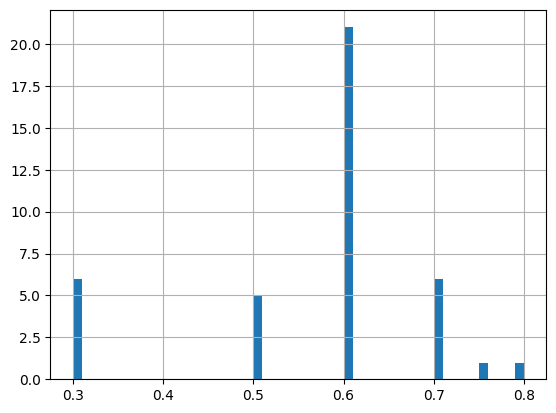

In [16]:
df.controversy_score.hist(bins=50)

<Axes: >

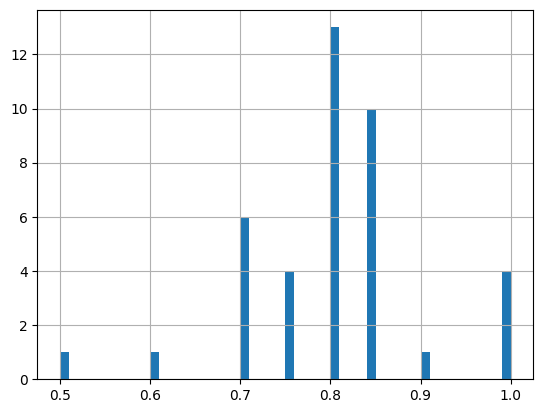

In [17]:
df.contribution_score.hist(bins=50)

<Axes: >

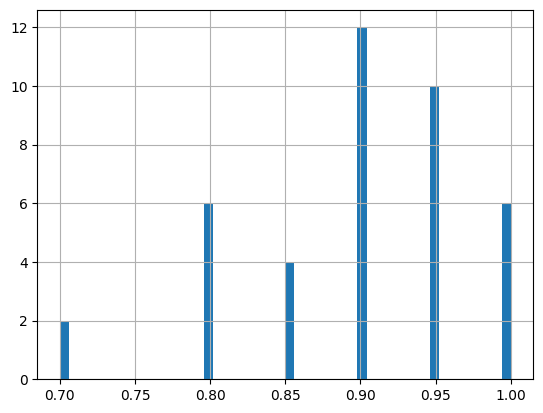

In [18]:
df.relevancy_score.hist(bins=50)

<Axes: >

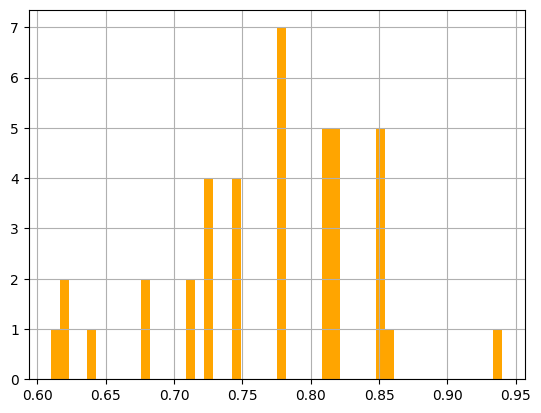

In [28]:
df.opinion_hotness.hist(bins=50, color='orange')